# Plot synthetic phase-mixture benchmarks

Configure the datasets, ranks, and models in the next cell, then run all cells. Each dataset gets its own figure. Missing result files and unavailable models are skipped.

In [106]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd

if Path("overview_paper/fmri_phase_state_sampler.py").exists():
    from overview_paper.fmri_phase_state_sampler import sample_fixed, sample_oscillatory
else:
    from fmri_phase_state_sampler import sample_fixed, sample_oscillatory

## Plot settings

Use `None` to plot every available model, or enter a list of model names. You can include only one dataset if desired.

In [107]:
DATASETS = ["oscillatory", "fixed"]
RANKS = [1, 3]

MODELS = {
    "oscillatory": None,  # Example: ["Complex ACG", "Complex Watson", "MACG"]
    "fixed": None,        # Example: ["Complex ACG", "Singular Wishart"]
}

VMVM_MODELS = {
    "VMVM (ordinary torus)",
    "VMVM (ordinary torus, uniform marginals)",
    "VMVM (quotient torus)",
}
VMVM_MODEL_BY_DATASET = {
    "oscillatory": "VMVM (ordinary torus, uniform marginals)",
    "fixed": "VMVM (ordinary torus)",
}

# Works whether Jupyter starts in the repository root or in overview_paper.
OVERVIEW_DIR = Path("overview_paper") if Path("overview_paper").is_dir() else Path(".")
RESULTS_DIR = OVERVIEW_DIR / "synthetic_results"

SAVE_FIGURES = True
DPI = 300
MAX_PLOTTED_NOISE = 3 * np.pi / 2
# Number of lowest sampled noise levels to omit: use 0, 1, 2, ...
INITIAL_NOISE_POINTS_TO_DROP = 2

# === Figure layout controls (edit these for final manual adjustments) ===
# Individual oscillatory/fixed figures, in inches. Their height grows once
# per available rank/result panel.
INDIVIDUAL_FIGURE_WIDTH = 6
INDIVIDUAL_FIGURE_HEIGHT_BASE = 3.2
INDIVIDUAL_FIGURE_HEIGHT_PER_RESULT_PANEL = 4

# Fractions of the individual figure width. The phase panel should be no
# wider than the result panels. The unused right side holds legends.
PHASE_PANEL_WIDTH_FRACTION = 0.9
RESULTS_PANEL_WIDTH_FRACTION = 0.76
PHASE_PANEL_HEIGHT_RATIO = 0.64
RESULT_PANEL_HEIGHT_RATIO = 1.0
# (left, bottom, right, top) in figure fractions. Vertical spacing is a
# fraction of the average panel height; increase it for larger gaps.
INDIVIDUAL_LAYOUT_RECT = (0, 0, 1, 0.96)
PANEL_VERTICAL_SPACING = 0.25
# Fine adjustment after automatic layout: (x shift, y shift, width change,
# height change), all as fractions of the whole figure. Positive x/y moves
# right/up; positive width/height makes that panel larger.
PHASE_PANEL_POSITION_ADJUSTMENT = (0.0, 0.0, 0.0, 0.0)
RESULT_PANEL_POSITION_ADJUSTMENTS = {
    1: (0.0, 0.0, 0.0, 0.0),
    3: (0.0, 0.0, 0.0, 0.0),
}

# Phase-panel annotations. Y values are in phase-panel data coordinates.
PHASE_CLUSTER_LABEL_Y = 6.15
PHASE_Y_LIMITS = (-0.6, 7.0)
PHASE_CLUSTER_LABEL_FONT_SIZE = 7.5
PHASE_TITLE_FONT_SIZE = 10
PHASE_XLABEL_FONT_SIZE = 8

# Legend/text locations below are (x, y) fractions of the whole figure.
PHASE_MANIFOLD_LEGEND_POSITION = (1.01, 0.84)
COHERENCE_MANIFOLD_LEGEND_POSITION = (1.02, 0.77)
MANIFOLD_LEGEND_BOX_POSITION = (0.87, 0.74)
MANIFOLD_LEGEND_BOX_SIZE = (0.3, 0.13)
RESULT_LEGEND_POSITION = (1.02, 0.5)  # axes-fraction coordinates
# Manual positions for the large dataset titles. These are whole-figure
# fractions: increase x to move right and y to move up.
DATASET_TITLE_POSITIONS = {
    "oscillatory": (0.60, 1.01),
    "fixed": (0.60, 1.01),
}

# Side-by-side oscillatory/fixed composite. WSPACE is the gap as a fraction
# of the average axes width; use 0 for no gap.
COMPOSITE_WIDTH_PER_ASPECT = 6.0
COMPOSITE_HEIGHT = 6.0
COMPOSITE_WSPACE = 0

# Example shown above the benchmark curves.
PHASE_EXAMPLE_NOISE = np.pi
PHASE_EXAMPLE_SAMPLES_PER_CLUSTER = 75
PHASE_EXAMPLE_SEED = 1

In [108]:
MANIFOLD_COLORS = {
    "ordinary torus": "#E76F51",
    "quotient torus": "#F4A261",
    "complex projective": "#2A9D8F",
    "real projective": "#457B9D",
    "Grassmann": "#8E6CBE",
    "weighted Grassmann": "#D65DB1",
    "Euclidean": "#4D4D4D",
}

# Marker grammar: circles denote mixture models and triangles denote K-means.
# A square distinguishes a second mixture model on the same manifold.
METHOD_STYLE = {
    "VMVM (ordinary torus)": ("ordinary torus", "-", "o"),
    "VMVM (ordinary torus, uniform marginals)": ("ordinary torus", "-", "o"),
    "Wrapped normal (ordinary torus)": ("ordinary torus", "-", "s"),
    "Torus K-means (ordinary torus)": ("ordinary torus", "--", "^"),
    "VMVM (quotient torus)": ("quotient torus", "-", "o"),
    "Wrapped normal (quotient torus)": ("quotient torus", "-", "s"),
    "Torus K-means (quotient torus)": ("quotient torus", "--", "^"),
    "Complex Watson": ("complex projective", "-", "o"),
    "Complex ACG": ("complex projective", "-", "s"),
    "Complex Bingham": ("complex projective", "-", "P"),
    "Complex diametrical K-means": ("complex projective", "--", "^"),
    # "Real Watson": ("real projective", "-", "o"),
    "Real ACG": ("real projective", "-", "s"),
    "Diametrical K-means": ("real projective", "--", "^"),
    "MACG": ("Grassmann", "-", "o"),
    "Grassmann K-means": ("Grassmann", "--", "^"),
    "Singular Wishart": ("weighted Grassmann", "-", "o"),
    "Weighted Grassmann K-means": ("weighted Grassmann", "--", "^"),
    # "Complex Normal": ("complex projective", "-", "D"),
    # "Normal (leading eigenvector)": ("Euclidean", "-", "o"),
    "Least-squares K-means": ("real projective", "--", "o"),
}

METHOD_LABELS = {
    "VMVM (ordinary torus, uniform marginals)": "UMVM (quotient torus)",
    "Least-squares K-means": "Least-squares K-means\n(leading cosine eigenvector)",
    "Torus K-means (quotient torus)": "quotient torus K-means",
}

In [109]:
def result_path(dataset, rank):
    filename = f"synthetic_phase_mixture_nmi_over_noise_{dataset}_rank={rank}.csv"
    path = RESULTS_DIR / filename
    if path.exists():
        return path

    # Results created before the dataset was added to the filename were
    # oscillatory. Keep them usable without renaming them.
    if dataset == "oscillatory":
        legacy = RESULTS_DIR / f"synthetic_phase_mixture_nmi_over_noise_rank={rank}.csv"
        if legacy.exists():
            print(f"Using legacy oscillatory result: {legacy.name}")
            return legacy
    return path


def load_available_results(dataset):
    loaded = {}
    for rank in RANKS:
        path = result_path(dataset, rank)
        if path.exists():
            scores = pd.read_csv(path)
            if INITIAL_NOISE_POINTS_TO_DROP < 0:
                raise ValueError("INITIAL_NOISE_POINTS_TO_DROP must be nonnegative")
            if INITIAL_NOISE_POINTS_TO_DROP and not scores.empty:
                initial_noise_levels = (
                    np.sort(scores["noise"].dropna().unique())
                    [:INITIAL_NOISE_POINTS_TO_DROP]
                )
                scores = scores.loc[
                    ~scores["noise"].isin(initial_noise_levels)
                ].copy()
            loaded[rank] = scores
        else:
            print(f"Skipping missing file: {path.name}")
    return loaded


def sampled_noise_cap(values):
    """Return the sampled noise level nearest the requested plotting cap."""
    noise = np.sort(values["noise"].dropna().unique())
    return noise[np.argmin(np.abs(noise - MAX_PLOTTED_NOISE))]


def finite_curve_through_noise_cap(values):
    """Finite sampled curve points through the noise level nearest the cap."""
    curve = values.loc[:, ["noise", "NMI"]].dropna().sort_values("noise")
    cap = sampled_noise_cap(values)
    return curve.loc[curve["noise"] <= cap].copy()


def normalized_auc_through_noise_cap(values):
    """AUC as a percentage of the maximum area over the observed interval."""
    curve = finite_curve_through_noise_cap(values)
    if len(curve) < 2:
        return np.nan
    width = curve["noise"].iloc[-1] - curve["noise"].iloc[0]
    return np.trapz(curve["NMI"], curve["noise"]) / width if width > 0 else np.nan


def plot_phase_example(ax, dataset, rank):
    sampler = {"oscillatory": sample_oscillatory, "fixed": sample_fixed}[dataset]
    theta, true_labels = sampler(
        noise=PHASE_EXAMPLE_NOISE,
        rank=rank,
        n_per_state=PHASE_EXAMPLE_SAMPLES_PER_CLUSTER,
        seed=PHASE_EXAMPLE_SEED,
    )

    # Put the six circular phase traces in separate horizontal bands, with
    # Phase 1 at the top.
    phase_positions = np.arange(theta.shape[1])[::-1]
    phase_bands = theta / (2 * np.pi) + phase_positions[None, :]
    x = np.arange(len(theta))
    boundary = np.flatnonzero(np.diff(true_labels))[0] + 0.5
    cluster_colors = ("#E8F1FA", "#FCE8DF")
    ax.axvspan(-0.5, boundary, color=cluster_colors[0], zorder=0)
    ax.axvspan(boundary, len(theta) - 0.5, color=cluster_colors[1], zorder=0)

    for region in range(theta.shape[1]):
        for cluster in np.unique(true_labels):
            in_cluster = true_labels == cluster
            ax.plot(x[in_cluster], phase_bands[in_cluster, region],
                    color="#303030", linewidth=0.85)

    centers = ((boundary - 0.5) / 2, boundary + (len(theta) - boundary - 0.5) / 2)
    ax.text(centers[0], PHASE_CLUSTER_LABEL_Y,
            "True cluster 1\nsynchronized relative phases",
            ha="center", va="bottom",
            fontsize=PHASE_CLUSTER_LABEL_FONT_SIZE, fontweight="bold")
    ax.text(centers[1], PHASE_CLUSTER_LABEL_Y,
            "True cluster 2\nevenly spaced relative phases",
            ha="center", va="bottom",
            fontsize=PHASE_CLUSTER_LABEL_FONT_SIZE, fontweight="bold")
    ax.axvline(boundary, color="#555555", linewidth=1.2, linestyle=":")
    ax.set_xlim(-0.5, len(theta) - 0.5)
    ax.set_ylim(*PHASE_Y_LIMITS)
    ax.set_yticks(phase_positions, [f"Phase {i + 1}" for i in range(theta.shape[1])])
    ax.set_xlabel("Synthetic sample", fontsize=PHASE_XLABEL_FONT_SIZE)
    ax.set_title(
        "Example synthetic phases (noise = π)",
        fontsize=PHASE_TITLE_FONT_SIZE,
    )
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.15)


def plot_dataset(dataset):
    results = load_available_results(dataset)
    if not results:
        print(f"No result files found for {dataset}; no figure created.")
        return None

    figure_height = (
        INDIVIDUAL_FIGURE_HEIGHT_BASE
        + INDIVIDUAL_FIGURE_HEIGHT_PER_RESULT_PANEL * len(results)
    )
    fig = plt.figure(figsize=(INDIVIDUAL_FIGURE_WIDTH, figure_height))
    grid = fig.add_gridspec(
        len(results) + 1, 3,
        height_ratios=[PHASE_PANEL_HEIGHT_RATIO]
        + [RESULT_PANEL_HEIGHT_RATIO] * len(results),
        width_ratios=[
            PHASE_PANEL_WIDTH_FRACTION,
            RESULTS_PANEL_WIDTH_FRACTION - PHASE_PANEL_WIDTH_FRACTION,
            1 - RESULTS_PANEL_WIDTH_FRACTION,
        ],
    )
    example_ax = fig.add_subplot(grid[0, 0])
    result_axes = [fig.add_subplot(grid[row, :2]) for row in range(1, len(results) + 1)]
    selected = MODELS.get(dataset)
    example_rank = max(results)
    plot_phase_example(example_ax, dataset, example_rank)

    for ax, (rank, scores) in zip(result_axes, results.items()):
        available = list(scores["model"].drop_duplicates())
        models = available if selected is None else [m for m in selected if m in available]
        skipped = [] if selected is None else [m for m in selected if m not in available]
        selected_vmvm = VMVM_MODEL_BY_DATASET[dataset]
        models = [
            model for model in models
            if model not in VMVM_MODELS or model == selected_vmvm
        ]
        if selected_vmvm not in available:
            skipped.append(selected_vmvm)
        if skipped:
            print(f"Skipping unavailable {dataset} rank={rank} models: {skipped}")

        styled_models = [model for model in models if model in METHOD_STYLE]
        for model in models:
            if model not in METHOD_STYLE:
                print(f"Skipping model without a defined style: {model}")

        # Sort best-to-worst by AUC through 3π/2. Missing NMI values are
        # omitted, so they neither invalidate the AUC nor contribute area.
        model_auc = {}
        for model in styled_models:
            values = scores.loc[scores["model"] == model]
            model_auc[model] = normalized_auc_through_noise_cap(values)

        auc_sort_key = lambda model: np.nan_to_num(model_auc[model], nan=-np.inf)
        for model in sorted(styled_models, key=auc_sort_key, reverse=True):
            raw_values = scores.loc[scores["model"] == model].sort_values("noise")
            noise_cap = sampled_noise_cap(raw_values)
            values = raw_values.loc[raw_values["noise"] <= noise_cap].copy()
            manifold, linestyle, marker = METHOD_STYLE[model]
            base_label = METHOD_LABELS.get(model, model)
            auc_label = (
                f"{model_auc[model]:.2%}" if np.isfinite(model_auc[model]) else "n/a"
            )
            ax.plot(values["noise"], values["NMI"], color=MANIFOLD_COLORS[manifold],
                    linestyle=linestyle, marker=marker, markersize=5, linewidth=1.8,
                    label=f"{base_label} (AUC: {auc_label})")

        subtitle = "Isotropic noise" if rank == 1 else f"Anisotropic noise, rank-{rank}"
        ax.set_title(subtitle, fontsize=12, fontweight="semibold")
        ax.set_xlabel("Noise arc width (radians)")
        ax.set_ylabel("Normalized mutual information (NMI)")
        minimum_noise = scores["noise"].min()
        noise_cap = sampled_noise_cap(scores)
        ax.set_xlim(minimum_noise, noise_cap)
        ax.set_ylim(-0.02, 1.02)
        ax.set_xticks([np.pi / 2, np.pi, noise_cap], ["π/2", "π", "3π/2"])
        ax.grid(alpha=0.25)
        if styled_models:
            legend = ax.legend(loc="center left",
                               bbox_to_anchor=RESULT_LEGEND_POSITION,
                               frameon=False, fontsize=8, handlelength=4.5,
                               handletextpad=0.8, numpoints=1, borderaxespad=0)
            # Make the solid/dashed distinction legible alongside the markers.
            for line in legend.get_lines():
                line.set_linewidth(2.8)
                line.set_markersize(7)

    dataset_title_x, dataset_title_y = DATASET_TITLE_POSITIONS[dataset]
    fig.suptitle(
        f"{dataset.capitalize()} phases",
        x=dataset_title_x, y=dataset_title_y,
        fontsize=18, fontweight="bold",
    )
    layout_left, layout_bottom, layout_right, layout_top = INDIVIDUAL_LAYOUT_RECT
    fig.subplots_adjust(
        left=layout_left, bottom=layout_bottom,
        right=layout_right, top=layout_top,
        hspace=PANEL_VERTICAL_SPACING,
    )

    def adjust_panel_position(ax, adjustment):
        x_shift, y_shift, width_change, height_change = adjustment
        position = ax.get_position()
        ax.set_position([
            position.x0 + x_shift, position.y0 + y_shift,
            position.width + width_change, position.height + height_change,
        ])

    adjust_panel_position(example_ax, PHASE_PANEL_POSITION_ADJUSTMENT)
    for rank, ax in zip(results, result_axes):
        adjust_panel_position(
            ax, RESULT_PANEL_POSITION_ADJUSTMENTS.get(rank, (0, 0, 0, 0))
        )
    if dataset in {"oscillatory", "fixed"}:
        phase_manifolds = ["ordinary torus", "quotient torus", "complex projective"]
        coherence_manifolds = ["weighted Grassmann", "Grassmann", "real projective"]

        def manifold_handles(manifolds):
            return [
                Line2D([0], [0], color=MANIFOLD_COLORS[manifold], linewidth=4,
                       label=manifold)
                for manifold in manifolds
            ]

        phase_legend = fig.legend(
            handles=manifold_handles(phase_manifolds), title="Phase-models",
            loc="center", bbox_to_anchor=PHASE_MANIFOLD_LEGEND_POSITION,
            frameon=False,
            fontsize=8, title_fontsize=9, handlelength=2.8,
        )
        phase_legend.set_in_layout(False)
        coherence_legend = fig.legend(
            handles=manifold_handles(coherence_manifolds),
            title="cosine phase coherence", loc="center",
            bbox_to_anchor=COHERENCE_MANIFOLD_LEGEND_POSITION, frameon=False,
            fontsize=8, title_fontsize=9, handlelength=2.8,
        )
        coherence_legend.set_in_layout(False)
        manifold_legend_box = FancyBboxPatch(
            MANIFOLD_LEGEND_BOX_POSITION, *MANIFOLD_LEGEND_BOX_SIZE,
            boxstyle="round,pad=0.006", transform=fig.transFigure,
            facecolor="white", edgecolor="#777777", linewidth=0.8,
            zorder=4, clip_on=False,
        )
        manifold_legend_box.set_in_layout(False)
        fig.add_artist(manifold_legend_box)
        phase_legend.set_zorder(5)
        coherence_legend.set_zorder(5)
    if SAVE_FIGURES:
        output = RESULTS_DIR / f"synthetic_phase_mixture_{dataset}.png"
        fig.savefig(output, dpi=DPI, bbox_inches="tight")
        print(f"Saved {output.name}")
    plt.show()
    return fig


def plot_manifold_color_legend():
    handles = [
        Line2D([0], [0], color=color, linewidth=4, label=manifold)
        for manifold, color in MANIFOLD_COLORS.items()
    ]
    fig, ax = plt.subplots(figsize=(4.8, 2.8))
    ax.axis("off")
    ax.legend(handles=handles, loc="center", frameon=False, fontsize=10,
              handlelength=3.5, title="Manifold", title_fontsize=11)
    fig.tight_layout()
    if SAVE_FIGURES:
        output = RESULTS_DIR / "synthetic_phase_mixture_manifold_colors.png"
        fig.savefig(output, dpi=DPI, bbox_inches="tight", transparent=True)
        print(f"Saved {output.name}")
    plt.show()
    return fig

Skipping model without a defined style: Complex projective hyperplane K-means
Skipping model without a defined style: Complex projective hyperplane K-means
Saved synthetic_phase_mixture_oscillatory.png


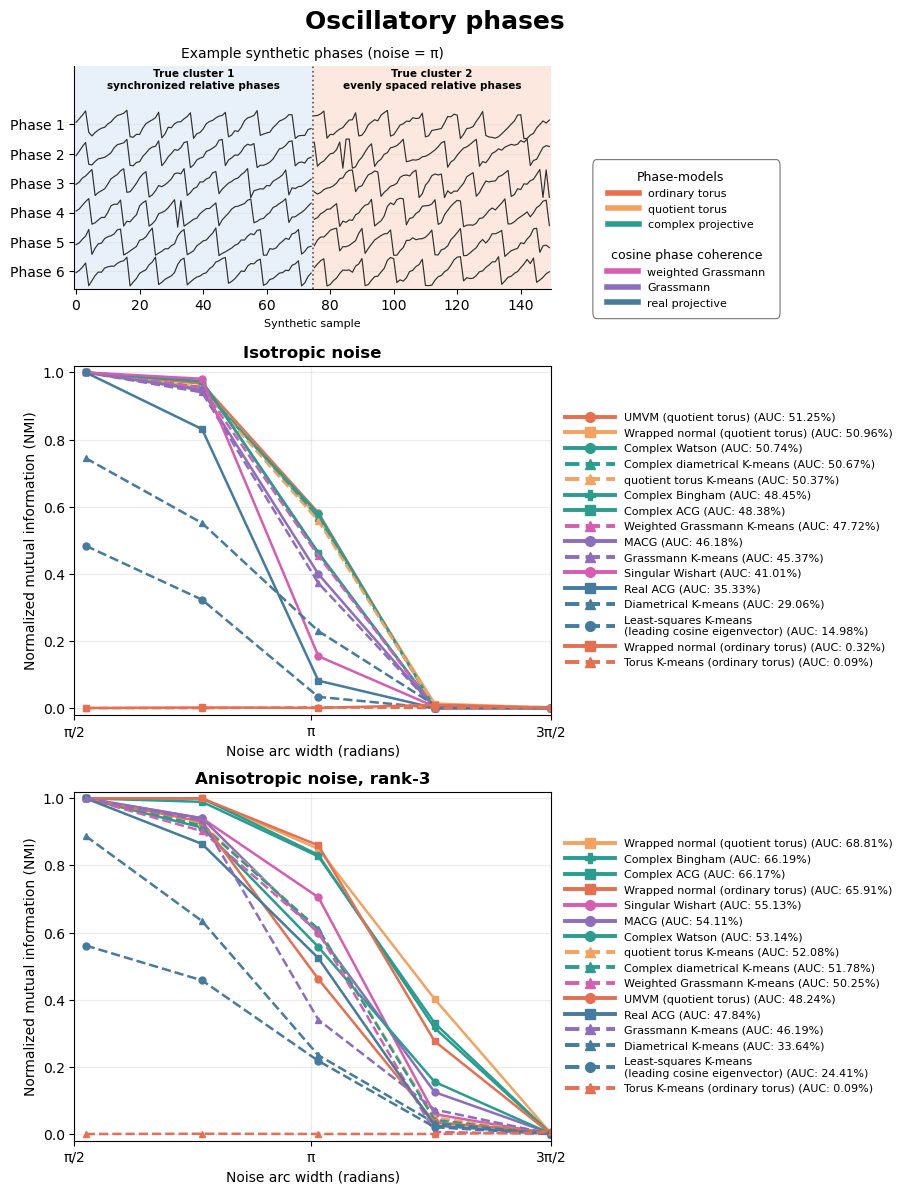

Skipping model without a defined style: Complex projective hyperplane K-means
Skipping model without a defined style: Complex projective hyperplane K-means
Saved synthetic_phase_mixture_fixed.png


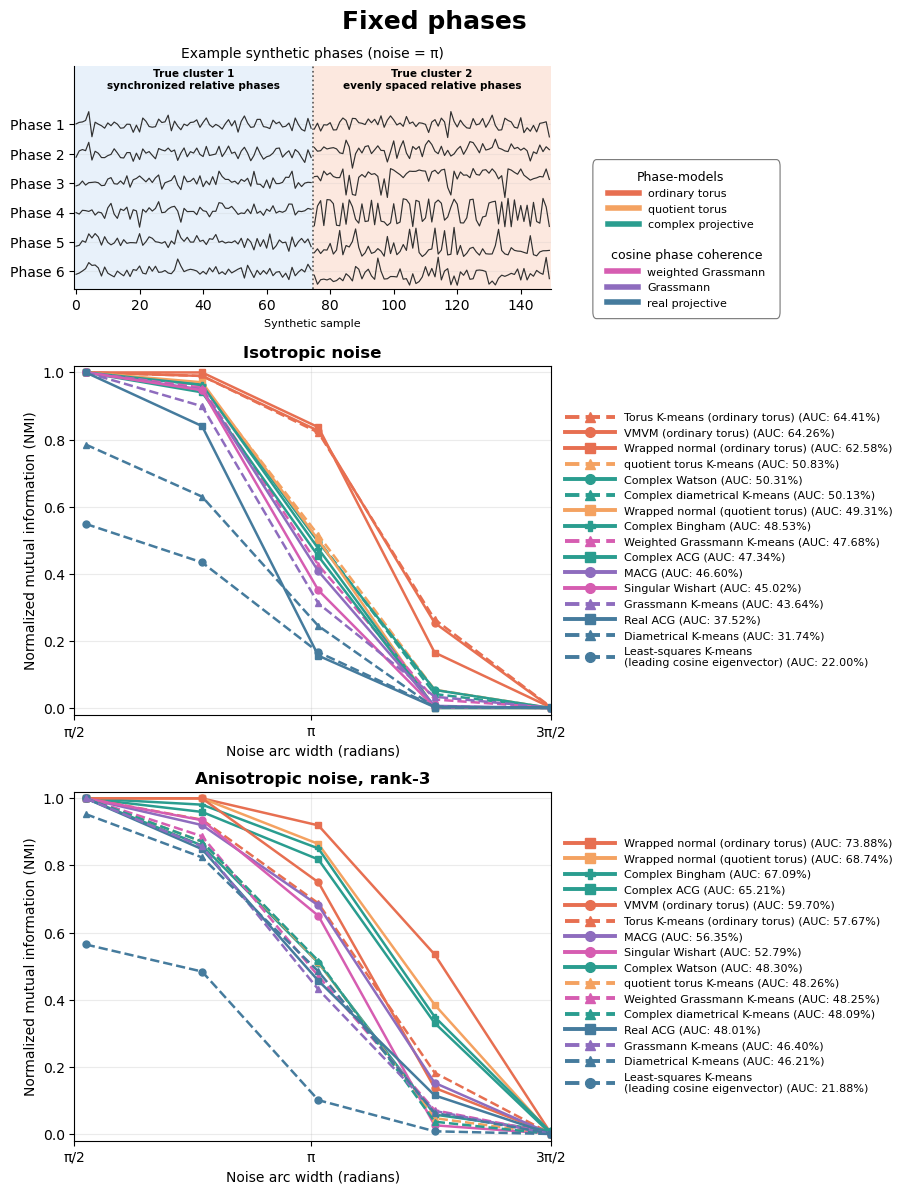

Saved synthetic_phase_mixture_oscillatory_and_fixed.png


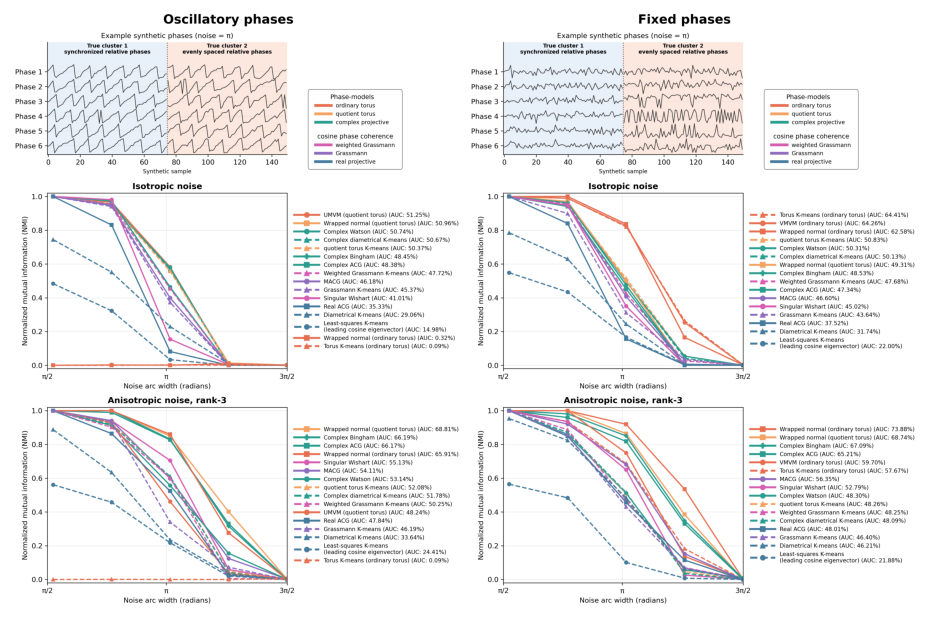

In [110]:
figures = {dataset: plot_dataset(dataset) for dataset in DATASETS}
# manifold_color_legend = plot_manifold_color_legend()

# Additional composite; the two existing dataset figures are left unchanged.
side_by_side_paths = [
    RESULTS_DIR / "synthetic_phase_mixture_oscillatory.png",
    RESULTS_DIR / "synthetic_phase_mixture_fixed.png",
]
if all(path.exists() for path in side_by_side_paths):
    side_by_side_images = [plt.imread(path) for path in side_by_side_paths]
    aspect_ratios = [image.shape[1] / image.shape[0] for image in side_by_side_images]
    side_by_side_figure, side_by_side_axes = plt.subplots(
        1, 2,
        figsize=(COMPOSITE_WIDTH_PER_ASPECT * sum(aspect_ratios), COMPOSITE_HEIGHT),
        gridspec_kw={"width_ratios": aspect_ratios},
    )
    for ax, image in zip(side_by_side_axes, side_by_side_images):
        ax.imshow(image)
        ax.axis("off")
    side_by_side_figure.subplots_adjust(
        left=0, right=1, bottom=0, top=1, wspace=COMPOSITE_WSPACE
    )
    if SAVE_FIGURES:
        output = RESULTS_DIR / "synthetic_phase_mixture_oscillatory_and_fixed.png"
        side_by_side_figure.savefig(output, dpi=DPI, bbox_inches="tight", pad_inches=0)
        print(f"Saved {output.name}")
    plt.show()
else:
    missing = [path.name for path in side_by_side_paths if not path.exists()]
    print(f"Skipping side-by-side figure; missing: {missing}")